# # Innovación: comparación de dos temporadas (2022 vs. 2023)
#
# **Grupo 9**
#
# **¿Por qué este notebook?** En nuestra temporada asignada (2022), gob.pe solo tiene **1 decreto de emergencia por lluvias** de la PCM (DS 032-2022-PCM). Con un solo decreto, la variable `declaratorias` solo puede valer 0 o 1, y no se puede ver si hay una relación con la lluvia. En la Parte 1 verificamos que no era un error de nuestro scraping: probamos 6 términos de búsqueda distintos y todos dan el mismo resultado.
#
# Para responder mejor la pregunta, repetimos **el mismo procedimiento** para la temporada **2023** (1 de enero al 31 de mayo), que fue muy distinta: hubo **ciclón Yaku y Niño costero** en el norte. Así comparamos:
# - ¿Cambia la respuesta cuando hay muchos decretos?
# - ¿Llovió más en 2023? ¿Dónde?
#
# Usamos las **mismas coordenadas** de las capitales de la Parte 2 (ya verificadas) y la misma lista de departamentos y reglas de clasificación de la Parte 1. Los archivos de este notebook se guardan con el prefijo `extra_2023_` para no mezclarlos con los obligatorios.

In [1]:
import re
import time
import calendar

import pandas as pd
import requests
from bs4 import BeautifulSoup
import plotly.graph_objects as go
from IPython.display import Image, display

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import NoSuchElementException

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 110)

AÑO = 2023
HEADERS = {"User-Agent": "Mozilla/5.0"}
NOMBRE_MES = {1: "enero", 2: "febrero", 3: "marzo", 4: "abril", 5: "mayo"}

# ## 1. Scraping de decretos 2023 (mismo código que la Parte 1)
#
# En 2023 algunos meses podrían tener más de 25 resultados, así que aquí la **paginación** sí puede ser necesaria.

In [2]:
BASE = ("https://www.gob.pe/busquedas?contenido[]=normas&institucion[]=pcm"
        "&term=estado%20de%20emergencia%20precipitaciones&sort_by=recent")


def url_mes(mes, año=AÑO):
    ultimo_dia = calendar.monthrange(año, mes)[1]
    return f"{BASE}&desde=01-{mes:02d}-{año}&hasta={ultimo_dia:02d}-{mes:02d}-{año}"


def leer_total(driver):
    texto = driver.find_element(By.TAG_NAME, "body").text
    if "No se encontraron resultados" in texto:
        return 0
    m = re.search(r"(\d+)\s+Resultados?\b", texto)
    return int(m.group(1)) if m else None


def abrir_busqueda(driver, url):
    driver.get(url)
    espera = WebDriverWait(driver, 30)
    espera.until(lambda d: leer_total(d) is not None)
    if leer_total(driver) > 0:
        espera.until(EC.presence_of_element_located((By.TAG_NAME, "article")))


def extraer_articulos(driver):
    filas = []
    for art in driver.find_elements(By.TAG_NAME, "article"):
        a = art.find_element(By.CSS_SELECTOR, "a.link-principal")
        fecha = art.find_element(By.XPATH, ".//span[starts-with(normalize-space(.), 'Publicado:')]").text
        try:
            titulo = art.find_element(By.TAG_NAME, "p").text
        except NoSuchElementException:
            titulo = ""
        filas.append({"numero": a.text.strip(), "fecha_texto": fecha.replace("Publicado:", "").strip(),
                      "titulo_corto": titulo.strip(), "enlace": a.get_attribute("href")})
    return filas


def scrapear_mes(driver, mes):
    abrir_busqueda(driver, url_mes(mes))
    total = leer_total(driver)
    filas = extraer_articulos(driver)
    while len(filas) < total:
        botones = driver.find_elements(By.CSS_SELECTOR, "button[aria-label^='Siguiente']")
        if not botones or not botones[0].is_enabled():
            break
        primer_articulo = driver.find_element(By.TAG_NAME, "article")
        time.sleep(2)
        botones[0].click()
        WebDriverWait(driver, 30).until(EC.staleness_of(primer_articulo))
        WebDriverWait(driver, 30).until(EC.presence_of_element_located((By.TAG_NAME, "article")))
        filas += extraer_articulos(driver)
    return total, filas


opciones = webdriver.ChromeOptions()
opciones.add_argument("--headless=new")
opciones.add_argument("--window-size=1400,3000")
driver = webdriver.Chrome(options=opciones)

todas, verificacion = [], []
for mes in NOMBRE_MES:
    total, filas = scrapear_mes(driver, mes)
    todas += filas
    verificacion.append({"mes": f"{NOMBRE_MES[mes]} {AÑO}", "resultados_totales": total,
                         "resultados_extraidos": len(filas)})
    time.sleep(2)
driver.quit()

verificacion = pd.DataFrame(verificacion)
verificacion["coinciden"] = verificacion["resultados_totales"] == verificacion["resultados_extraidos"]
print(verificacion.to_string(index=False))
assert verificacion["coinciden"].all()

         mes  resultados_totales  resultados_extraidos  coinciden
  enero 2023                  11                    11       True
febrero 2023                   9                     9       True
  marzo 2023                  14                    14       True
  abril 2023                  11                    11       True
   mayo 2023                   8                     8       True


In [3]:
normas = pd.DataFrame(todas).drop_duplicates(subset="enlace").reset_index(drop=True)
antes = len(normas)
normas = normas[normas["enlace"].str.contains("/institucion/pcm/", regex=False)].reset_index(drop=True)
print(f"Normas únicas: {antes} | De otras instituciones (quitadas): {antes - len(normas)} | PCM: {len(normas)}")


def titulo_completo(enlace):
    sopa = BeautifulSoup(requests.get(enlace, headers=HEADERS).text, "html.parser")
    descripcion = sopa.find("div", class_="description")
    if descripcion is None:
        return None
    return (descripcion.find("div") or descripcion).get_text(" ", strip=True)


titulos = []
for enlace in normas["enlace"]:
    titulos.append(titulo_completo(enlace))
    time.sleep(1)
normas["titulo"] = titulos
print("Títulos vacíos:", normas["titulo"].isna().sum())

Normas únicas: 53 | De otras instituciones (quitadas): 4 | PCM: 49


Títulos vacíos: 0


# ## 2. Clasificación y departamentos (mismas reglas de la Parte 1)

In [4]:
def es_lluvia(t):
    t = t.lower()
    return "lluvia" in t or "precipitaciones" in t

def tipo(t):
    t = t.lower()
    if "prórroga" in t or "prorroga" in t:
        return "prorroga"
    elif "declara" in t:
        return "declara"
    return "otro"

def motivo(t):
    t = t.lower()
    if "peligro inminente" in t:
        return "peligro inminente"
    elif "impacto de daños" in t:
        return "impacto de daños"
    return "otro"

departamentos = ["Amazonas", "Áncash", "Apurímac", "Arequipa", "Ayacucho",
                 "Cajamarca", "Callao", "Cusco", "Huancavelica", "Huánuco",
                 "Ica", "Junín", "La Libertad", "Lambayeque", "Lima", "Loreto",
                 "Madre de Dios", "Moquegua", "Pasco", "Piura", "Puno",
                 "San Martín", "Tacna", "Tumbes", "Ucayali"]

def departamentos_mencionados(titulo):
    return [d for d in departamentos if re.search(r"\b" + d + r"\b", titulo)]

normas["es_lluvia"] = normas["titulo"].apply(es_lluvia)
normas["tipo"] = normas["titulo"].apply(tipo)
normas["motivo"] = normas["titulo"].apply(motivo)

lluvias23 = normas[normas["es_lluvia"]].reset_index(drop=True)
lluvias23["departamentos"] = lluvias23["titulo"].apply(departamentos_mencionados)
print("Normas de lluvias en 2023:", len(lluvias23))
print(pd.crosstab(lluvias23["tipo"], lluvias23["motivo"], margins=True))
lluvias23[["numero", "fecha_texto", "tipo", "motivo", "departamentos"]]

Normas de lluvias en 2023: 20
motivo    impacto de daños  otro  peligro inminente  All
tipo                                                    
declara                 13     1                  3   17
prorroga                 2     1                  0    3
All                     15     2                  3   20


,numero,fecha_texto,tipo,motivo,departamentos
0,Decreto Supremo N.° 008-2023-PCM,13 de enero de 2023,declara,peligro inminente,"[Amazonas, Áncash, Arequipa, Ayacucho, Cajamarca, Huancavelica, Huánuco, Junín, La Libertad, Lima, Loreto,..."
1,Decreto Supremo N.° 007-2023-PCM,13 de enero de 2023,declara,impacto de daños,"[Amazonas, Áncash, Cusco, Huánuco, La Libertad, San Martín, Ucayali]"
2,Decreto Supremo N.° 024-2023-PCM,17 de febrero de 2023,declara,impacto de daños,[Lima]
3,Decreto Supremo N.° 019-2023-PCM,6 de febrero de 2023,declara,impacto de daños,[Arequipa]
4,Decreto Supremo N.° 044-2023-PCM,29 de marzo de 2023,declara,impacto de daños,"[Huánuco, Ica]"
5,Decreto Supremo N.° 043-2023-PCM,26 de marzo de 2023,declara,otro,"[Lambayeque, Piura, Tumbes]"
6,Decreto Supremo N.° 0039-2023-PCM,18 de marzo de 2023,declara,impacto de daños,"[Amazonas, Ayacucho, Pasco, Ucayali]"
7,Decreto Supremo N.° 038-2023-PCM,18 de marzo de 2023,declara,impacto de daños,"[Áncash, Huancavelica, Ica, Lima]"
8,Decreto Supremo N.° 035-2023-PCM,12 de marzo de 2023,declara,peligro inminente,"[Áncash, Apurímac, Arequipa, Ayacucho, Callao, Cusco, Huancavelica, Huánuco, Ica, Junín, Lima, Moquegua, P..."
9,Decreto Supremo N.° 034-2023-PCM,12 de marzo de 2023,declara,impacto de daños,"[Cajamarca, La Libertad, Lambayeque, Piura]"


# Revisamos los decretos de lluvias que **no mencionan ningún departamento** en el título (por ejemplo, una emergencia *nacional*) y los que quedaron con tipo o motivo `"otro"`:

In [5]:
revisar = lluvias23[(lluvias23["departamentos"].str.len() == 0) | (lluvias23["tipo"] == "otro")
                    | (lluvias23["motivo"] == "otro")]
for _, f in revisar.iterrows():
    print(f["numero"], "|", f["tipo"], "|", f["motivo"], "|", f["departamentos"])
    print("   ", f["titulo"], "\n")

Decreto Supremo N.° 043-2023-PCM | declara | otro | ['Lambayeque', 'Piura', 'Tumbes']
    Decreto Supremo que declara el Estado de Emergencia Nacional, por desastre de gran magnitud, a consecuencia de intensas precipitaciones pluviales en los departamentos de Lambayeque, Piura y Tumbes 

Decreto Supremo N.° 065-2023-PCM | prorroga | otro | ['Lambayeque', 'Piura', 'Tumbes']
    Decreto Supremo que prorroga el Estado de Emergencia Nacional, por desastre de gran magnitud, a consecuencia de intensas precipitaciones pluviales en varios distritos de las provincias de los departamentos de Lambayeque, Piura y Tumbes 



Todos los decretos de lluvias de 2023 mencionan al menos un departamento. Los dos con motivo `"otro"` (DS 043-2023-PCM y su prórroga, el DS 065-2023-PCM) declaran el **Estado de Emergencia Nacional por desastre de gran magnitud** en Lambayeque, Piura y Tumbes, por el ciclón Yaku y el Niño costero. No dicen "peligro inminente" ni "impacto de daños", así que la regla los clasifica bien como "otro". En la práctica son una tercera categoría: se declaran **después** de un desastre muy grande, más cerca de "impacto de daños" que de la prevención.

In [6]:
por_dep = (lluvias23.explode("departamentos").rename(columns={"departamentos": "departamento"})
           .dropna(subset=["departamento"]).reset_index(drop=True))
conteo = pd.crosstab(por_dep["departamento"], por_dep["tipo"])
for col in ["declara", "prorroga"]:
    if col not in conteo.columns:
        conteo[col] = 0
decretos23 = (conteo.reindex(departamentos, fill_value=0).rename_axis(index="departamento", columns=None)
              .reset_index().rename(columns={"declara": "declaratorias", "prorroga": "prorrogas"})
              [["departamento", "declaratorias", "prorrogas"]])
print("Filas:", len(decretos23))
decretos23.sort_values("declaratorias", ascending=False).head(12)

Filas: 25


,departamento,declaratorias,prorrogas
1,Áncash,6,1
14,Lima,6,0
4,Ayacucho,5,1
12,La Libertad,5,0
3,Arequipa,4,0
21,San Martín,4,0
9,Huánuco,4,0
5,Cajamarca,4,0
0,Amazonas,3,1
13,Lambayeque,3,1


# ## 3. Lluvia 2023 en las mismas capitales (Open-Meteo)
#
# Reutilizamos las coordenadas verificadas en la Parte 2 (`lluvias_por_departamento.csv`) y pedimos la lluvia diaria del 1 de enero al 31 de mayo de 2023.

In [7]:
coords = pd.read_csv("datos/lluvias_por_departamento.csv")[["departamento", "capital", "latitud", "longitud"]]

filas = []
for _, f in coords.iterrows():
    params = {"latitude": f["latitud"], "longitude": f["longitud"], "start_date": f"{AÑO}-01-01",
              "end_date": f"{AÑO}-05-31", "daily": "precipitation_sum", "timezone": "America/Lima"}
    r = requests.get("https://archive-api.open-meteo.com/v1/archive", params=params)
    r.raise_for_status()
    s = pd.Series(r.json()["daily"]["precipitation_sum"], dtype="float")
    filas.append({"departamento": f["departamento"], "dias": len(s), "dias_sin_dato": int(s.isna().sum()),
                  "lluvia_total_mm": round(s.sum(), 1), "dias_lluvia_fuerte": int((s >= 20).sum())})
    time.sleep(1)

lluvia23 = pd.DataFrame(filas)
print("Días por capital:", lluvia23["dias"].unique(), "| Días sin dato en total:", lluvia23["dias_sin_dato"].sum())
lluvia23 = lluvia23.drop(columns=["dias", "dias_sin_dato"])

Días por capital: [151] | Días sin dato en total: 0


# ## 4. Cruce por ubigeo y tabla comparativa

In [8]:
ubigeos = pd.read_csv("datos/ubigeos.csv", dtype={"ubigeo": str})
t22 = pd.read_csv("datos/tabla_final.csv", dtype={"ubigeo": str})

t23 = (ubigeos.merge(lluvia23, on="departamento", how="left")
              .merge(decretos23, on="departamento", how="left"))
assert len(t23) == 25 and t23.isna().sum().sum() == 0
t23.to_csv("datos/extra_2023_tabla_final.csv", index=False, encoding="utf-8-sig")
lluvias23[["numero", "fecha_texto", "titulo", "tipo", "motivo", "enlace"]].to_csv(
    "datos/extra_2023_decretos_lluvias.csv", index=False, encoding="utf-8-sig")

comp = t22[["ubigeo", "departamento", "lluvia_total_mm", "dias_lluvia_fuerte", "declaratorias", "prorrogas"]].merge(
    t23[["ubigeo", "lluvia_total_mm", "dias_lluvia_fuerte", "declaratorias", "prorrogas"]],
    on="ubigeo", suffixes=("_2022", "_2023"))
comp["cambio_lluvia_pct"] = ((comp["lluvia_total_mm_2023"] / comp["lluvia_total_mm_2022"] - 1) * 100).round(0)
assert len(comp) == 25
comp.sort_values("declaratorias_2023", ascending=False)

,ubigeo,departamento,lluvia_total_mm_2022,dias_lluvia_fuerte_2022,declaratorias_2022,prorrogas_2022,lluvia_total_mm_2023,dias_lluvia_fuerte_2023,declaratorias_2023,prorrogas_2023,cambio_lluvia_pct
1,02,Áncash,975.3,7,0,0,1145.8,9,6,1,17.0
14,15,Lima,13.9,0,0,0,27.9,0,6,0,101.0
4,05,Ayacucho,485.1,0,1,0,498.4,2,5,1,3.0
12,13,La Libertad,98.9,1,0,0,177.2,1,5,0,79.0
3,04,Arequipa,189.9,0,0,0,362.0,1,4,0,91.0
21,22,San Martín,789.8,4,0,0,1050.5,12,4,0,33.0
9,10,Huánuco,444.8,1,0,0,524.3,2,4,0,18.0
5,06,Cajamarca,773.3,1,0,0,796.6,0,4,0,3.0
0,01,Amazonas,436.5,1,1,0,414.6,3,3,1,-5.0
13,14,Lambayeque,98.8,0,0,0,445.8,4,3,1,351.0


In [9]:
def spearman(a, b):
    """Correlación de Spearman = correlación de Pearson entre los rankings (sin necesitar scipy)."""
    return round(a.rank().corr(b.rank()), 2)


resumen = pd.DataFrame({
    "temporada": ["2022", "2023"],
    "decretos_de_lluvias": [int(pd.read_csv("datos/decretos_lluvias.csv").shape[0]), len(lluvias23)],
    "declaratorias_(suma_por_departamento)": [comp["declaratorias_2022"].sum(), comp["declaratorias_2023"].sum()],
    "departamentos_con_declaratoria": [(comp["declaratorias_2022"] > 0).sum(), (comp["declaratorias_2023"] > 0).sum()],
    "lluvia_mediana_mm": [comp["lluvia_total_mm_2022"].median(), comp["lluvia_total_mm_2023"].median()],
    "correlacion_spearman_lluvia_vs_declaratorias": [
        spearman(comp["lluvia_total_mm_2022"], comp["declaratorias_2022"]),
        spearman(comp["lluvia_total_mm_2023"], comp["declaratorias_2023"])],
    "correlacion_spearman_dias_fuertes_vs_declaratorias": [
        spearman(comp["dias_lluvia_fuerte_2022"], comp["declaratorias_2022"]),
        spearman(comp["dias_lluvia_fuerte_2023"], comp["declaratorias_2023"])],
})
resumen.T

,0,1
temporada,2022,2023
decretos_de_lluvias,1,20
declaratorias_(suma_por_departamento),3,72
departamentos_con_declaratoria,3,24
lluvia_mediana_mm,485.1,714.0
correlacion_spearman_lluvia_vs_declaratorias,-0.15,-0.18
correlacion_spearman_dias_fuertes_vs_declaratorias,-0.26,-0.2


# La **correlación de Spearman** compara el *orden* de los departamentos: vale +1 si los que más llueven son siempre los que más declaratorias tienen, 0 si no hay relación y -1 si es al revés. La usamos en vez de la de Pearson porque las declaratorias son conteos pequeños con muchos ceros y unos pocos valores altos.

# **Otra forma de verlo: el cambio entre temporadas.** Si las declaratorias responden a la lluvia *anormal* (más de lo habitual) y no al total, los departamentos donde más **aumentó** la lluvia de 2022 a 2023 deberían ser los que más declaratorias **ganaron**.

In [10]:
comp["aumento_declaratorias"] = comp["declaratorias_2023"] - comp["declaratorias_2022"]
print("Spearman (cambio % de lluvia vs. aumento de declaratorias):",
      spearman(comp["cambio_lluvia_pct"], comp["aumento_declaratorias"]))
print("\nDepartamentos donde la lluvia aumentó más de 100 %:")
print(comp[comp["cambio_lluvia_pct"] > 100][["departamento", "lluvia_total_mm_2022", "lluvia_total_mm_2023",
                                             "cambio_lluvia_pct", "declaratorias_2022", "declaratorias_2023"]]
      .sort_values("cambio_lluvia_pct", ascending=False).to_string(index=False))

decl23 = lluvias23[lluvias23["tipo"] == "declara"]
print("\nMotivo de las declaratorias 2023 (%):")
print((decl23["motivo"].value_counts(normalize=True) * 100).round(1))

Spearman (cambio % de lluvia vs. aumento de declaratorias): 0.24

Departamentos donde la lluvia aumentó más de 100 %:
departamento  lluvia_total_mm_2022  lluvia_total_mm_2023  cambio_lluvia_pct  declaratorias_2022  declaratorias_2023
       Piura                  89.2                 719.4              707.0                   1                   3
    Moquegua                  17.8                  83.9              371.0                   0                   2
         Ica                  25.1                 113.6              353.0                   0                   3
  Lambayeque                  98.8                 445.8              351.0                   0                   3
      Tumbes                 332.3                 931.4              180.0                   0                   2
       Tacna                  11.5                  28.2              145.0                   0                   2
        Lima                  13.9                  27.9              

# ## 5. Gráficos

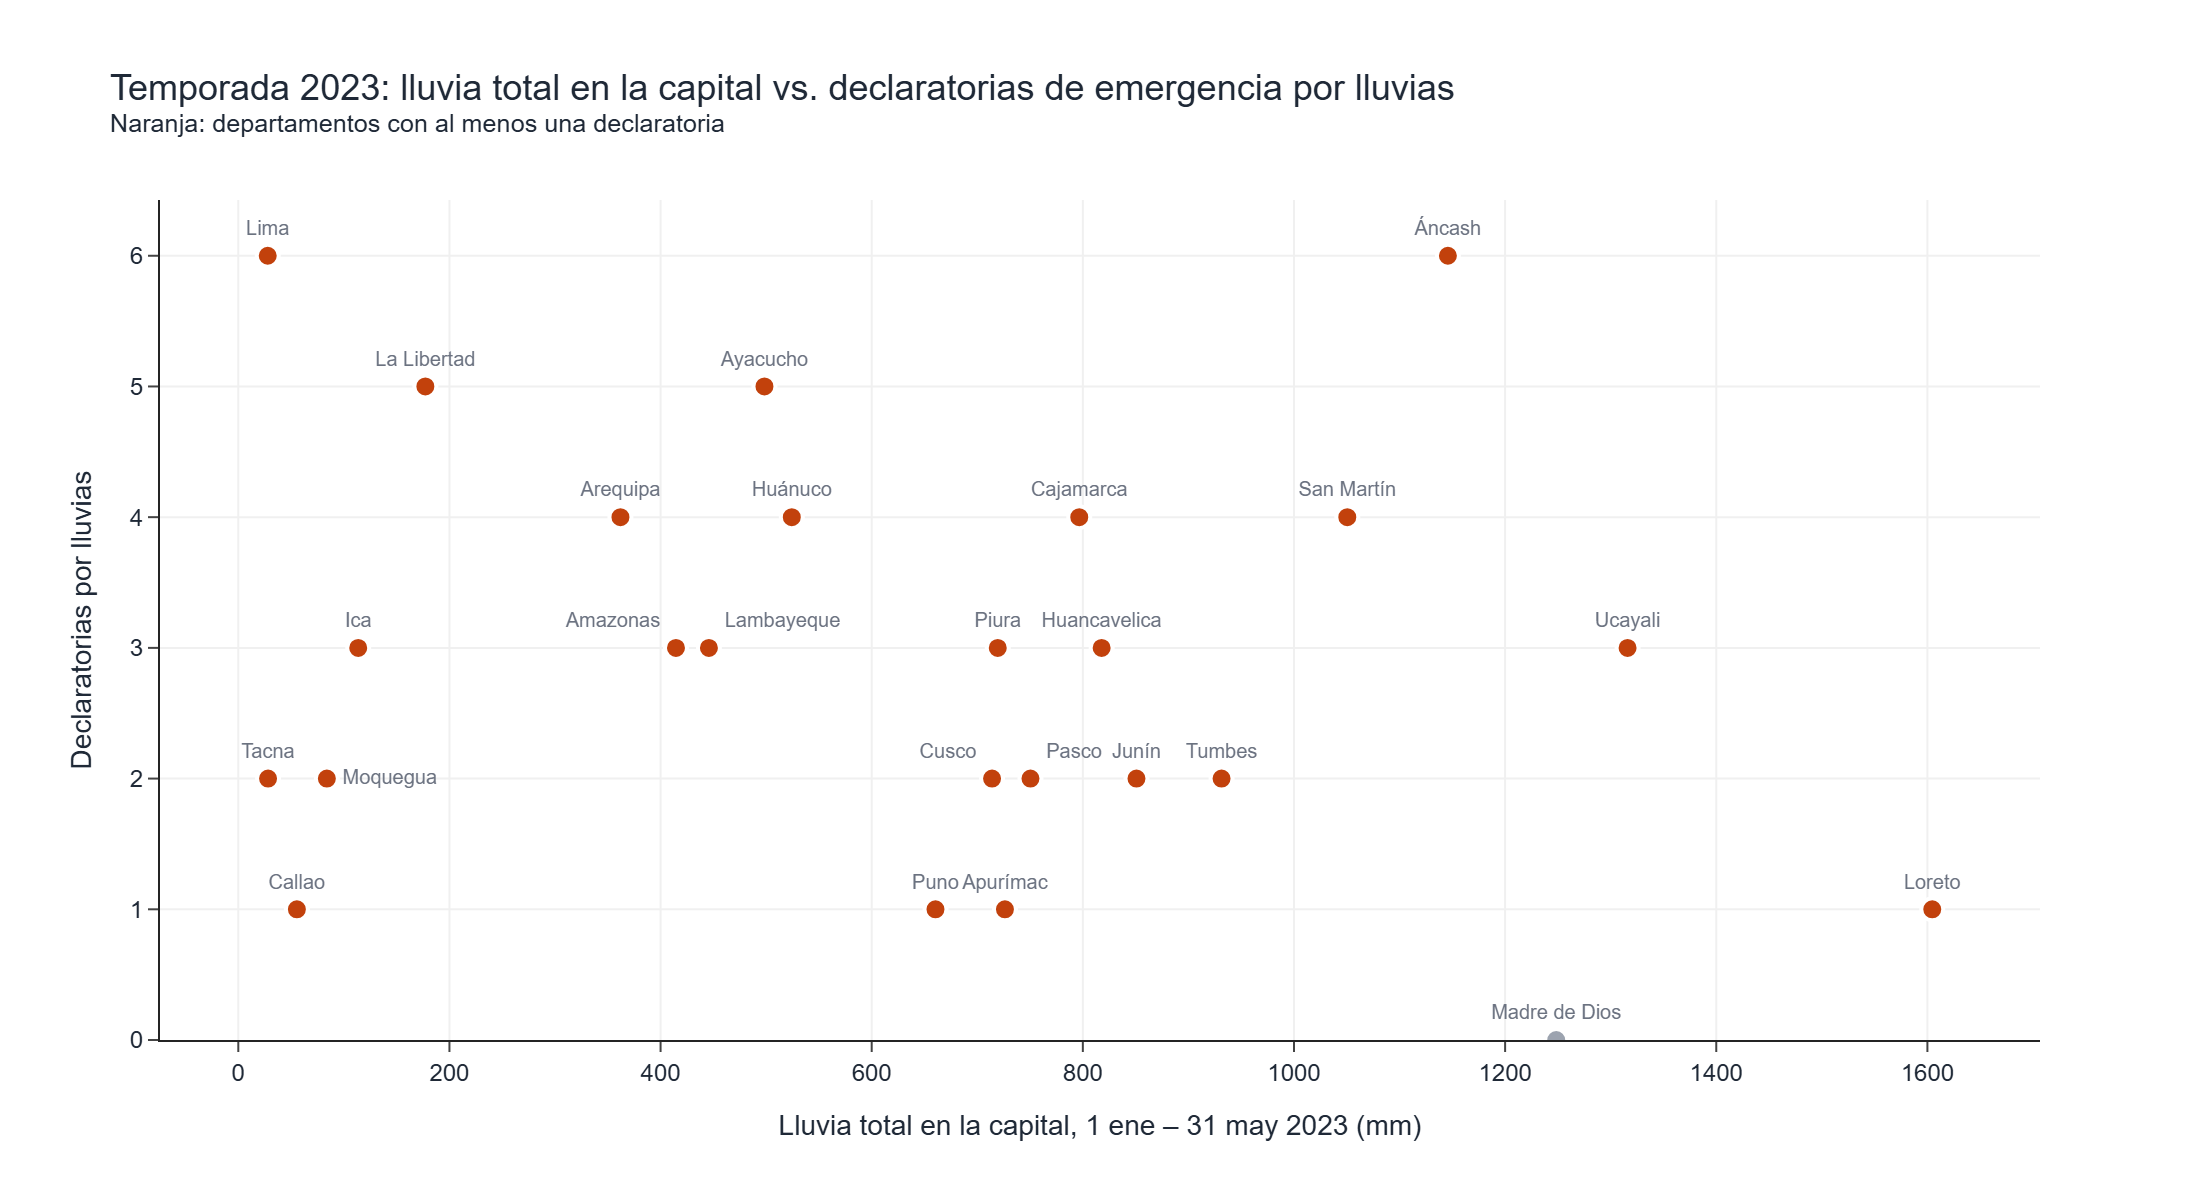

In [11]:
ACENTO, GRIS, TINTA, TINTA_SUAVE = "#c2410c", "#9ca3af", "#1f2937", "#6b7280"

# Posición de la etiqueta: arriba al centro, salvo los pares de puntos que quedan muy juntos
posicion = {"Amazonas": "top left", "Lambayeque": "top right", "Moquegua": "middle right",
            "Cusco": "top left", "Pasco": "top right"}
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=t23["lluvia_total_mm"], y=t23["declaratorias"], mode="markers+text", text=t23["departamento"],
    textposition=[posicion.get(d, "top center") for d in t23["departamento"]], textfont=dict(size=10, color=TINTA_SUAVE),
    marker=dict(size=11, color=[ACENTO if n > 0 else GRIS for n in t23["declaratorias"]],
                line=dict(width=2, color="white")),
    customdata=t23[["dias_lluvia_fuerte", "prorrogas"]],
    hovertemplate="<b>%{text}</b><br>Lluvia: %{x:,.1f} mm<br>Días ≥20 mm: %{customdata[0]}"
                  "<br>Declaratorias: %{y}<br>Prórrogas: %{customdata[1]}<extra></extra>"))
fig.update_layout(
    template="simple_white", width=1100, height=600, showlegend=False, font=dict(family="Arial", color=TINTA),
    title=dict(text="Temporada 2023: lluvia total en la capital vs. declaratorias de emergencia por lluvias"
                    "<br><sup>Naranja: departamentos con al menos una declaratoria</sup>", font=dict(size=18)),
    xaxis=dict(title="Lluvia total en la capital, 1 ene – 31 may 2023 (mm)", showgrid=True, gridcolor="#f0f0f0"),
    yaxis=dict(title="Declaratorias por lluvias", showgrid=True, gridcolor="#f0f0f0", rangemode="tozero"),
)
fig.show()
fig.write_image("graficos/extra_2023_dispersion.png", scale=2)
display(Image("graficos/extra_2023_dispersion.png", width=950))

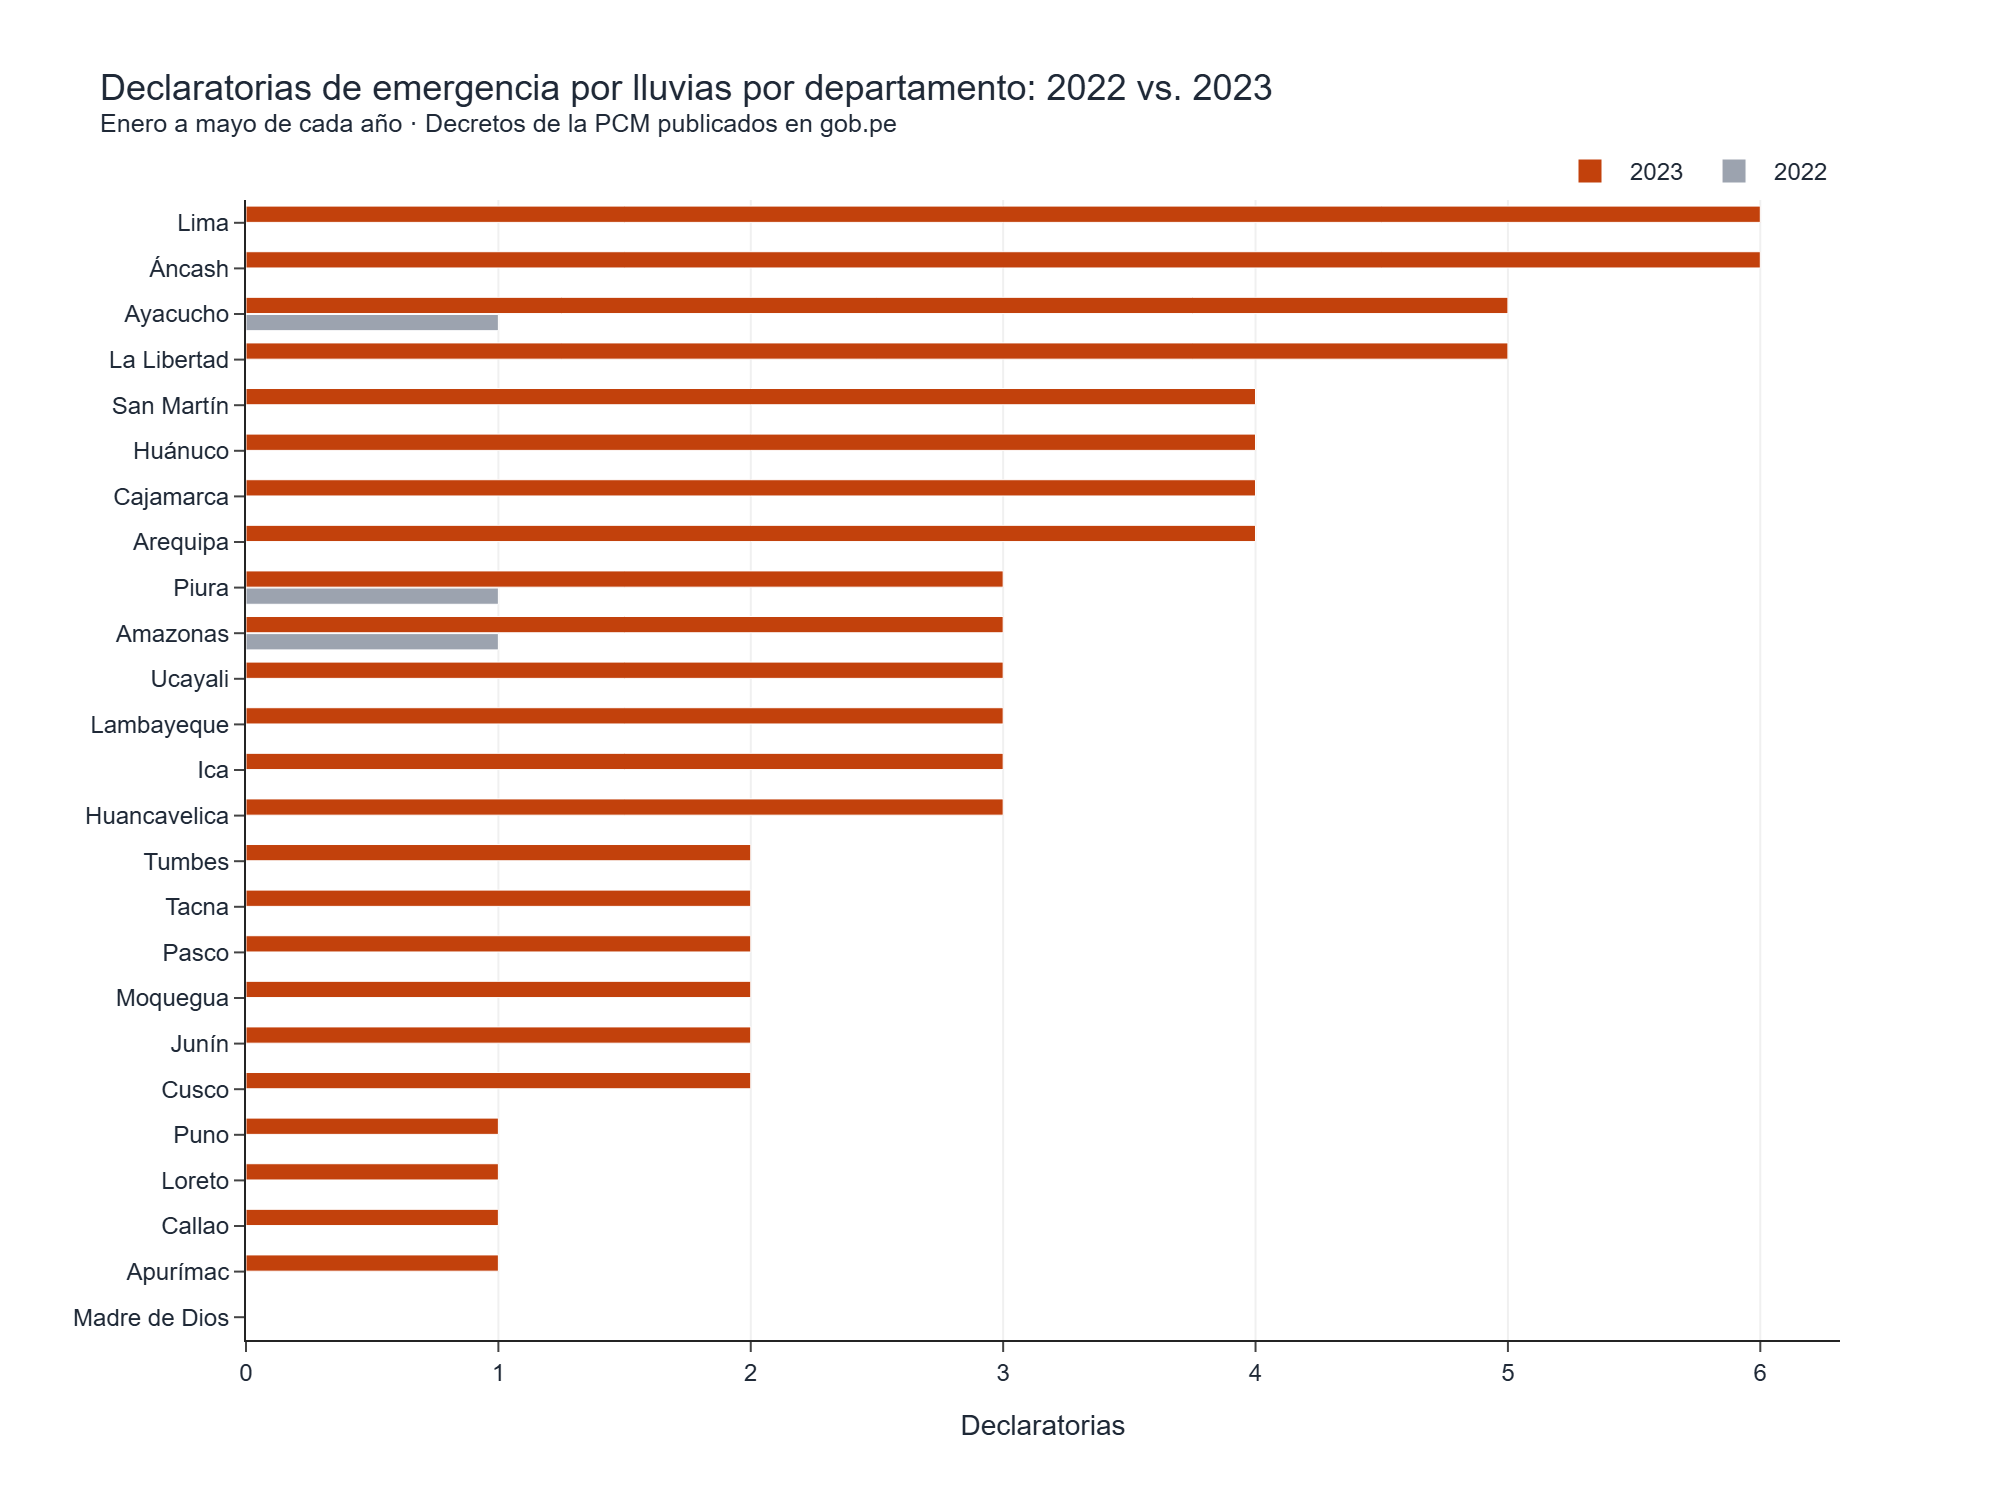

In [12]:
orden = comp.sort_values(["declaratorias_2023", "declaratorias_2022"], ascending=True)
fig = go.Figure()
fig.add_trace(go.Bar(y=orden["departamento"], x=orden["declaratorias_2022"], name="2022", orientation="h",
                     marker_color=GRIS))
fig.add_trace(go.Bar(y=orden["departamento"], x=orden["declaratorias_2023"], name="2023", orientation="h",
                     marker_color=ACENTO))
fig.update_layout(
    template="simple_white", width=1000, height=750, barmode="group", bargap=0.25, bargroupgap=0.05,
    font=dict(family="Arial", color=TINTA),
    title=dict(text="Declaratorias de emergencia por lluvias por departamento: 2022 vs. 2023"
                    "<br><sup>Enero a mayo de cada año · Decretos de la PCM publicados en gob.pe</sup>",
               font=dict(size=18)),
    xaxis=dict(title="Declaratorias", showgrid=True, gridcolor="#f0f0f0", dtick=1),
    yaxis=dict(title=""),
    legend=dict(orientation="h", x=1, xanchor="right", y=1.0, yanchor="bottom", traceorder="reversed"),
)
fig.show()
fig.write_image("graficos/extra_2022_vs_2023_declaratorias.png", scale=2)
display(Image("graficos/extra_2022_vs_2023_declaratorias.png", width=900))

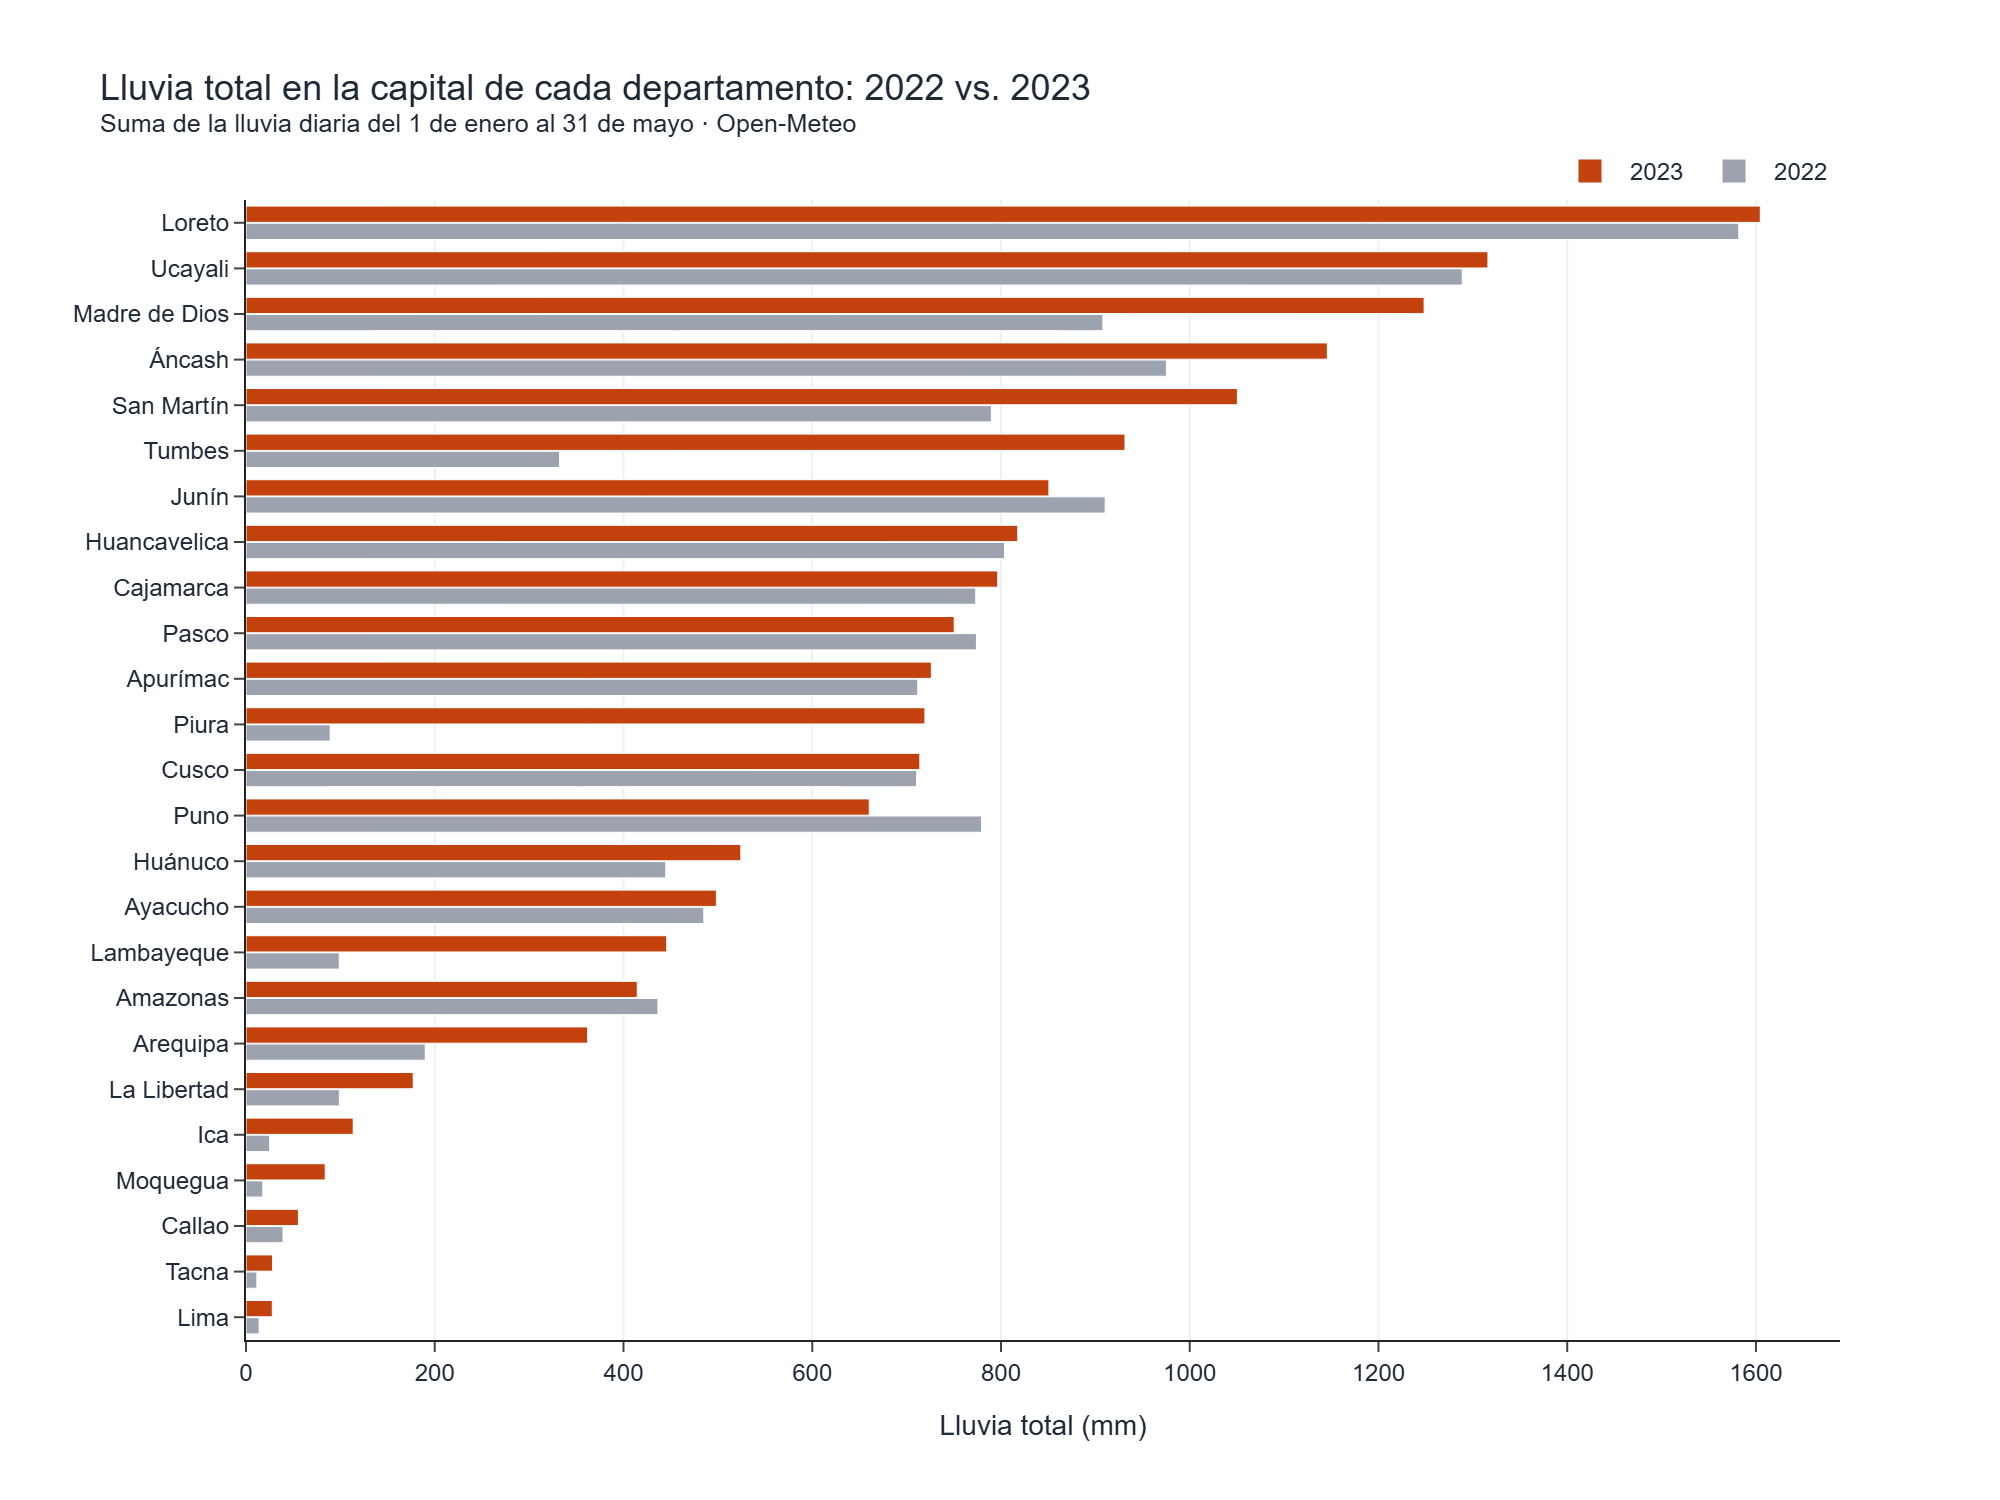

In [13]:
orden = comp.sort_values("lluvia_total_mm_2023", ascending=True)
fig = go.Figure()
fig.add_trace(go.Bar(y=orden["departamento"], x=orden["lluvia_total_mm_2022"], name="2022", orientation="h",
                     marker_color=GRIS))
fig.add_trace(go.Bar(y=orden["departamento"], x=orden["lluvia_total_mm_2023"], name="2023", orientation="h",
                     marker_color=ACENTO))
fig.update_layout(
    template="simple_white", width=1000, height=750, barmode="group", bargap=0.25, bargroupgap=0.05,
    font=dict(family="Arial", color=TINTA),
    title=dict(text="Lluvia total en la capital de cada departamento: 2022 vs. 2023"
                    "<br><sup>Suma de la lluvia diaria del 1 de enero al 31 de mayo · Open-Meteo</sup>",
               font=dict(size=18)),
    xaxis=dict(title="Lluvia total (mm)", showgrid=True, gridcolor="#f0f0f0"),
    yaxis=dict(title=""),
    legend=dict(orientation="h", x=1, xanchor="right", y=1.0, yanchor="bottom", traceorder="reversed"),
)
fig.show()
fig.write_image("graficos/extra_2022_vs_2023_lluvia.png", scale=2)
display(Image("graficos/extra_2022_vs_2023_lluvia.png", width=900))

# ## 6. ¿Qué aprendemos al comparar las dos temporadas?
#
**1. Las dos temporadas son muy distintas.** En 2023 hubo **20 decretos de lluvias** (contra 1 en 2022), y **24 de los 25 departamentos** tuvieron al menos una declaratoria (contra 3). La lluvia también cambió, sobre todo en la **costa**: en Piura pasó de 89 mm a 719 mm (+707 %), en Lambayeque de 99 a 446 mm (+351 %) y en Tumbes de 332 a 931 mm (+180 %). En la selva y la sierra, en cambio, la lluvia fue parecida en los dos años: Loreto, Ucayali, Cusco y Apurímac variaron menos de 3 %.
#
# **2. Ni siquiera en 2023 se declara más emergencia donde más llueve en total.** La correlación de Spearman entre la lluvia total y las declaratorias es **−0.18** en 2023 (−0.15 en 2022). Con los días de lluvia fuerte es −0.20 (−0.26 en 2022). Es decir, no hay relación, e incluso es levemente negativa. Hay ejemplos claros:
# - **Lima** tuvo **6 declaratorias** (el máximo, empatado con Áncash) con solo **27.9 mm** en su capital.
# - **Loreto**, el departamento más lluvioso (1 604.6 mm y 26 días de lluvia fuerte), tuvo **1**.
# - **Madre de Dios** (1 248.4 mm) tuvo **0**.
#
# **3. Lo que sí parece importar es la lluvia *anormal*.** Los **7 departamentos donde la lluvia más que se duplicó** (Piura, Moquegua, Ica, Lambayeque, Tumbes, Tacna y Lima, todos de la costa) recibieron entre 2 y 6 declaratorias en 2023. En 2022 tenían 0, salvo Piura, que tenía 1. La correlación entre el **aumento de la lluvia** y el **aumento de declaratorias** es positiva (**+0.24**), aunque débil. Esto tiene sentido: la selva está adaptada a llover mucho todos los años, pero en la costa desértica unas lluvias que en la selva serían normales activan quebradas y causan huaicos e inundaciones, porque las viviendas, los canales y las pistas no están preparados.
#
# **4. La gestión sigue siendo principalmente reactiva, pero en 2023 hubo algo de prevención.** De las 17 declaratorias de 2023, el **76.5 %** fue por **impacto de daños**, el **17.6 %** por **peligro inminente** y el **5.9 %** (1 decreto) fue la Emergencia Nacional por desastre de gran magnitud. En 2022, la única declaratoria fue por impacto de daños.
#
# **Respuesta a la pregunta con las dos temporadas:** **No, el Estado no declara emergencia donde más llueve en términos absolutos.** Las declaratorias se parecen más a un mapa de **lluvia fuera de lo normal** y de **vulnerabilidad** (la costa, Lima, las zonas de quebradas) que a un mapa de **cuánta lluvia cae**. Limitaciones: la lluvia sigue midiéndose solo en las capitales, una correlación de +0.24 con 25 departamentos es débil, y en gob.pe la temporada 2022 tiene muy pocos decretos.